In [1]:
#data format library
import h5py

#numpy
import numpy as np
import pandas as pd
import numpy.ma as ma
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
# plt.rcParams["font.family"] = "Times New Roman"
matplotlib.rcParams['pdf.fonttype'] = 42
# %matplotlib notebook
import sys
sys.path.append('./utils/')
import matplotlib.colors as pltcolors
import os
import copy
import partitioning_methods as cl
import diffusion_maps as dmaps
import operator_calculations as op_calc
import coarse_graining as cgm
import delay_embedding as embed
import stats
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import time as tt
import scipy

np.random.seed(42)

import importlib

In [2]:
Fig_path = '/flash/StephensU/Gautam/Figures/Comparing_MultiScale_Dynamics/FigS_3well_diffmaps/'
Texp_range = np.array(np.logspace(2,4.0,11),dtype=int)
Texp_range = np.hstack([[10,17,31,56],Texp_range])
print(Texp_range)

[   10    17    31    56   100   158   251   398   630  1000  1584  2511
  3981  6309 10000]


In [1]:
np.log10(10,17,31,56)

NameError: name 'np' is not defined

In [3]:
out_path = '/flash/StephensU/Gautam/HMD/Results/3well_pchip/'
f = h5py.File(out_path+'L_approx_metaData.h5','r')
labels_phen = np.array(f['labels_phen'])
phens = np.array(f['phens'])
Tx = np.array(f['Tx'])[0]
f.close()

In [4]:
D_int_list = []
Dc_q_data_list = []
Dc_q_eps_list = []
path_to_filtered_data = '/flash/StephensU/Gautam/HMD/Results/'
for Ti in Texp_range[:]:
    f = h5py.File(path_to_filtered_data + '/3well_pchip/T{}/distances_combined.h5'.format(Ti))
    Dc_q_data = np.array(f['Dc_q_data'],dtype=float)
    Dc_q_eps = np.array(f['Dc_q_eps'],dtype=float)
    q_range = np.array(f['q_range'],dtype=float)
    Dc_q_eps[Dc_q_eps == 0] = 1e-6
    f.close()
    Dc_q_data_list.append(Dc_q_data)
    Dc_q_eps_list.append(Dc_q_eps)
    D_ratio = Dc_q_data/(Dc_q_eps)-1
    for i in range(len(D_ratio)):
        np.fill_diagonal(D_ratio[i],0)
    # D_ratio = Dc_q_data-Dc_q_reg_eps
    
    D_ratio[D_ratio<0]=0
    D_int = np.trapz(D_ratio,q_range,axis=0)
    np.fill_diagonal(D_int,0)
    D_int_list.append(D_int)

In [5]:
print(Texp_range)

[   10    17    31    56   100   158   251   398   630  1000  1584  2511
  3981  6309 10000]


In [6]:
idx_to_check = [2,6,11]
print(Texp_range[2],Texp_range[6],Texp_range[11])
# idx_to_check = [11]

31 251 2511


/scratch/ipykernel_3823973/3797682076.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1.0)


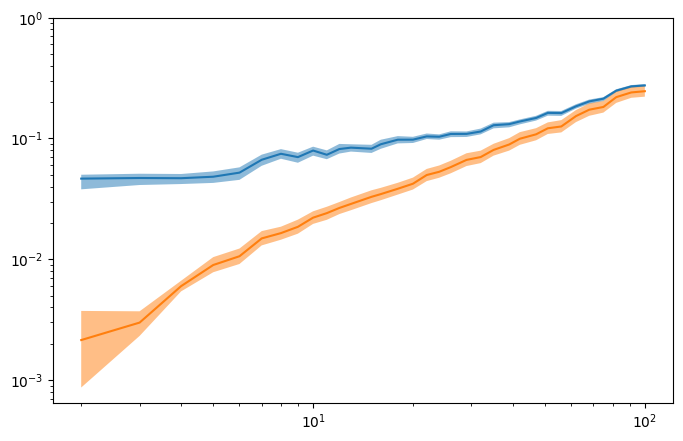

In [54]:
D_here = Dc_q_data_list[idx_to_check[2]]
Eps_here = Dc_q_eps_list[idx_to_check[2]]


plt.figure(figsize=(8,5))
mean = D_here.max(axis=2).mean(axis=1)
# mean= np.median(Dc_q_data.max(axis=2),axis=1)
cil = np.percentile(D_here.max(axis=2),2.5,axis=1)
ciu =  np.percentile(D_here.max(axis=2),97.5,axis=1)
plt.plot(q_range,mean,label='data')
plt.fill_between(q_range,cil,ciu,alpha=.5)

mean = Eps_here.max(axis=2).mean(axis=1)
# mean = np.median(Dc_q_eps.max(axis=2),axis=1)
cil = np.percentile(Eps_here.max(axis=2),2.5,axis=1)
ciu =  np.percentile(Eps_here.max(axis=2),97.5,axis=1)
plt.plot(q_range,mean,label='eps')
plt.fill_between(q_range,cil,ciu,alpha=.5)
# plt.axvline(20,c='k',ls='--')
# plt.axvline(3,c='k',ls='--')
# plt.axvline(12,c='k',ls='--')
# plt.axvline(91,c='k',ls='--')
plt.xscale('log')
plt.yscale('log')
# plt.xlabel('q')
# plt.ylabel('<D>')
plt.ylim(0,1.0)
# plt.savefig(Fig_path+'/dist_v_eps_cond1_cond2.pdf')
plt.show()

In [10]:
Ks = np.unique(np.array(np.logspace(0.5,2,50),dtype=int))
diff_eigs = []
D_int = D_int_list[11]
sorted_d = np.sort(D_int, axis=1)
from scipy.sparse.linalg import eigs
for k in Ks:
    print(k)
    M_ = dmaps.self_tuning_diffusion_tmat(D_int,sorted_d,k,1)
    diff_eig,_ = eigs(M_,k=10)
    
    sorted_indices = np.argsort(diff_eig.real)[::-1]
    diff_eig = diff_eig[sorted_indices].real
    diff_eig[diff_eig<1e-12] = 1e-12
    diff_eigs.append(diff_eig[1:])

3
4
5
6
7
8
9
10
11
12
13
14
15
17
18
19
21
22
24
26
28
30
32
34
37
39
42
46
49
53
56
61
65
70
75
80
86
93
100


In [11]:
diff_eigs = np.vstack(diff_eigs).T

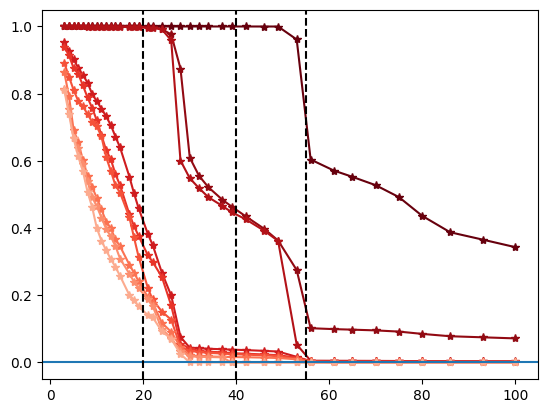

In [13]:
colors_ = plt.cm.Reds(np.linspace(0.3,1.,9))[::-1]
for i in range(9):
    plt.plot(Ks, diff_eigs[i],color = colors_[i],marker='*')
# plt.ylim(0,400)
plt.axhline(0)
plt.axvline(20,c='k',ls='--')
plt.axvline(40,c='k',ls='--')
plt.axvline(55,c='k',ls='--')
plt.savefig(Fig_path+'k_ei_texp11.pdf')
# plt.axvline(78,ls='--',label='My K')
# plt.legend()

In [71]:
from numpy.linalg import matrix_power
from scipy.sparse.linalg import eigs

k=55
D_int = D_int_list[idx_to_check[1]]
sorted_d = np.sort(D_int, axis=1)
M = dmaps.self_tuning_diffusion_tmat(D_int, sorted_d,k,1)

diff_eig, diff_ev = eigs(M,k=15)
# inv_measure = op_calc.stationary_distribution(P)
diff_eigvecs = diff_ev/np.linalg.norm(diff_ev,axis=0)

sorted_indices = np.argsort(diff_eig.real)[::-1]
diff_eig = diff_eig[sorted_indices].real
diff_dists = (diff_eig)*diff_eigvecs[:,sorted_indices].real

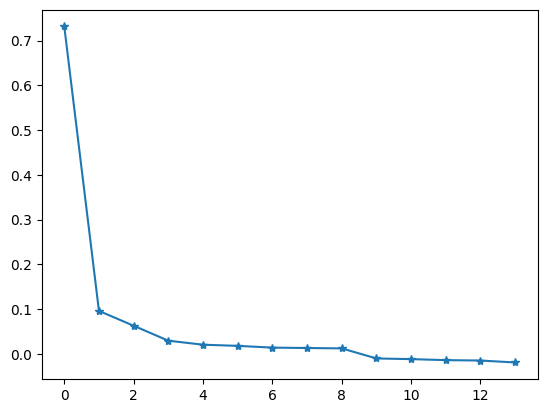

In [72]:
plt.plot(diff_eig[1:],marker='*')

0.0
1.0
2.0
3.0


(-0.09063016520401422,
 0.09599505192314459,
 -0.020723273255426354,
 0.026883097800716876)

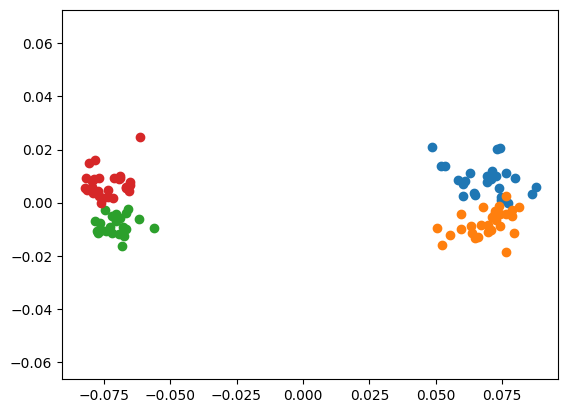

In [73]:
fig, ax = plt.subplots(1,1)
ha = labels_phen
for i in np.unique(ha):
    print(i)
    # ax.axvline(0.03)
    ax.scatter(diff_dists[ha==i,1].real, diff_dists[ha==i,2].real)
# cbar = fig.colorbar(im)
# cbar.set_label('Tumble Bias')
ax.axis('equal')
# plt.savefig(Fig_path+'Diffmap_Texp11_ei_k55.pdf')

In [49]:
from mpl_toolkits.mplot3d import Axes3D

def set_axes_equal(ax):
    """
    Make axes of 3D plot have equal scale so that spheres appear as spheres,
    cubes as cubes, etc.

    Input
      ax: a matplotlib axis, e.g., as output from plt.gca().
    """

    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    # The plot bounding box is a sphere in the sense of the infinity
    # norm, hence I call half the max range the plot radius.
    plot_radius = 0.5*max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])

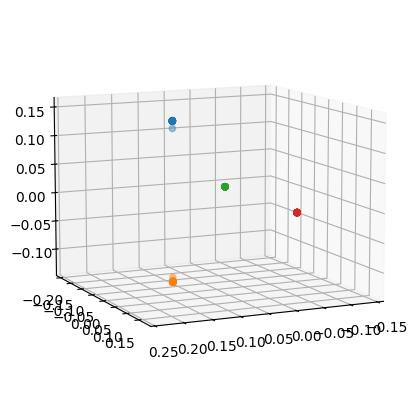

In [50]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(projection='3d')
ax.view_init(10,65)

# Define the range for x and y
# x_ = np.linspace(-1.7,-0.3, 100)
# y_ = np.linspace(-.95, -1.3, 100)

# Create a meshgrid for x and y
# X_, Y_ = np.meshgrid(x_, y_)

# Plot the plane
# ax.plot_surface(X_, Y_, m*Y_+b, alpha=.25, color='gray',rstride=100,cstride=100)


for kl in np.unique(labels_phen):
    ax.scatter(diff_dists[labels_phen==kl,1],diff_dists[labels_phen==kl,2],diff_dists[labels_phen==kl,3],alpha=0.4)

# ax.set_xlim(-0.05,0.05)
# ax.set_zlim(-0.05,0.05)
# ax.set_ylim(-0.05,0.05)
ax.axis('equal')
# plt.savefig(Fig_path + 'Diffmap_texp11_k20.pdf')